# Dataset Inspection — Audio-Conditioned Composed Fashion Retrieval

**Date:** 2026-04-20

**Purpose:** Verify that FACap and FashionIQ actually fit the project task before committing to them. Produce concrete visual samples of the data.

**Task recap:** `<reference garment image, spoken modification, target garment image>` → retrieve target. Modifications start as text in these datasets; we'll convert them to speech via TTS in a later phase.

**What's in this notebook:**
1. Load FashionIQ triplets for all 3 categories (dress, shirt, toptee).
2. Download ~20 Amazon-hosted FashionIQ images and render reference→target triplets with captions inline.
3. Load FACap triplets (6 categories) + image-level captions to see fine-grained modifications and target captions — text-only since FACap images live in Fashion200k and aren't downloaded yet.
4. Load enhFashionIQ (FACap's refined FashionIQ validation set) — same ASIN keys as FashionIQ, so we can show the refined caption next to the same images.
5. Fill the 6-question dataset-fit table with real observations.
6. Write the summary.

In [1]:
import json, os, io, textwrap, urllib.parse
from pathlib import Path
import requests
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = Path('/home/zhuoyuan/CSprojects/fashion-retrieval-agent/data_exploration')
FIQ = BASE / 'datasets' / 'fashion-iq'
FIQ_META = BASE / 'datasets' / 'fashion-iq-metadata' / 'image_url'
FACAP = BASE / 'datasets' / 'facap-repo' / 'data' / 'facap'
ENHFIQ = BASE / 'datasets' / 'facap-repo' / 'data' / 'fashioniq' / 'enhfashioniq_triplets'
IMG_CACHE = BASE / 'datasets' / 'fashion-iq-images'
IMG_CACHE.mkdir(exist_ok=True)

print('Paths resolved. FashionIQ captions dir exists:', (FIQ / 'captions').exists())
print('FACap data dir exists:', FACAP.exists())

Paths resolved. FashionIQ captions dir exists: True
FACap data dir exists: True


## 1. FashionIQ — structure and sizes

In [2]:
fiq_stats = []
for cat in ['dress', 'shirt', 'toptee']:
    row = {'category': cat}
    for split in ['train', 'val', 'test']:
        with open(FIQ / 'captions' / f'cap.{cat}.{split}.json') as f:
            row[f'{split}_triplets'] = len(json.load(f))
        with open(FIQ / 'image_splits' / f'split.{cat}.{split}.json') as f:
            row[f'{split}_gallery'] = len(json.load(f))
    fiq_stats.append(row)

display(Markdown('### FashionIQ — triplet and gallery counts'))
hdr = '| category | train triplets | val triplets | test triplets | train gallery | val gallery | test gallery |\n|---|---|---|---|---|---|---|'
rows = [hdr]
for r in fiq_stats:
    rows.append(f"| {r['category']} | {r['train_triplets']} | {r['val_triplets']} | {r['test_triplets']} | {r['train_gallery']} | {r['val_gallery']} | {r['test_gallery']} |")
display(Markdown('\n'.join(rows)))

# Raw sample
with open(FIQ / 'captions' / 'cap.dress.val.json') as f:
    fiq_dress_val = json.load(f)
print('\nRaw example triplet (dress/val[0]):')
print(json.dumps(fiq_dress_val[0], indent=2))

### FashionIQ — triplet and gallery counts

| category | train triplets | val triplets | test triplets | train gallery | val gallery | test gallery |
|---|---|---|---|---|---|---|
| dress | 5985 | 2017 | 2024 | 11452 | 3817 | 3818 |
| shirt | 5988 | 2038 | 2038 | 19036 | 6346 | 6346 |
| toptee | 6027 | 1961 | 2056 | 16121 | 5373 | 5374 |


Raw example triplet (dress/val[0]):
{
  "target": "B0084Y8XIU",
  "candidate": "B005X4PL1G",
  "captions": [
    "is shiny and silver with shorter sleeves",
    "fit and flare"
  ]
}


## 2. FashionIQ — download sample images and render triplets

Images live at Amazon URLs mapped by ASIN in `asin2url.<category>.txt`. We cache downloaded images locally.

In [3]:
def load_asin2url(cat):
    m = {}
    with open(FIQ_META / f'asin2url.{cat}.txt') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                m[parts[0].strip()] = parts[1].strip()
    return m

asin2url = {cat: load_asin2url(cat) for cat in ['dress', 'shirt', 'toptee']}
for cat, m in asin2url.items():
    print(f'{cat}: {len(m):,} ASIN->URL mappings')

dress: 19,087 ASIN->URL mappings
shirt: 31,728 ASIN->URL mappings
toptee: 26,868 ASIN->URL mappings


In [4]:
def fetch_image(asin, url, cat):
    """Return PIL.Image or None. Caches under IMG_CACHE/<cat>/<asin>.jpg."""
    cat_dir = IMG_CACHE / cat
    cat_dir.mkdir(exist_ok=True)
    path = cat_dir / f'{asin}.jpg'
    if path.exists():
        try:
            return Image.open(path).copy()
        except Exception:
            path.unlink()
    try:
        # URLs are http — upgrade to https defensively
        url = url.replace('http://', 'https://', 1)
        r = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
        if r.status_code == 200 and r.content:
            with open(path, 'wb') as f:
                f.write(r.content)
            return Image.open(path).copy()
    except Exception as e:
        print(f'  fail {asin}: {e}')
    return None

def render_fiq_triplet(ax_ref, ax_tgt, ref_img, tgt_img, captions, enh_caption=None):
    ax_ref.imshow(ref_img)
    ax_ref.set_title('reference', fontsize=10)
    ax_ref.axis('off')
    ax_tgt.imshow(tgt_img)
    ax_tgt.set_title('target', fontsize=10)
    ax_tgt.axis('off')
    joined = '\n'.join(f'• {c}' for c in captions)
    if enh_caption:
        joined += f'\n— enhFashionIQ refined —\n{textwrap.fill(enh_caption, 55)}'
    return joined

In [5]:
# Load enhFashionIQ for dress/shirt/toptee (keyed by candidate ASIN -> refined caption)
enh = {}
for cat in ['dress', 'shirt', 'toptee']:
    with open(ENHFIQ / f'cap.{cat}.val.json') as f:
        enh_list = json.load(f)
    # Index by (candidate, target) pair
    enh[cat] = {(e['candidate'], e['target']): e['captions'] for e in enh_list}
    print(f'enhFashionIQ/{cat} val: {len(enh_list)} refined triplets')

print('\nSample enhFashionIQ dress/val[0]:')
with open(ENHFIQ / 'cap.dress.val.json') as f:
    print(json.dumps(json.load(f)[0], indent=2))

enhFashionIQ/dress val: 3817 refined triplets
enhFashionIQ/shirt val: 6346 refined triplets
enhFashionIQ/toptee val: 5373 refined triplets

Sample enhFashionIQ dress/val[0]:
{
  "candidate": "B009PMCJLW",
  "target": "B00B44YE30",
  "captions": [
    "The dress is black, sleeveless, and has a flared peplum waist, contrasting with the deep burgundy color and long sleeves of the other dress."
  ]
}


In [6]:
# For each category, try to fetch images until we have N successful triplets.
# We prefer triplets where both candidate and target ASINs exist in asin2url.
def sample_triplets(cat, n=6, start=0):
    with open(FIQ / 'captions' / f'cap.{cat}.val.json') as f:
        data = json.load(f)
    selected = []
    m = asin2url[cat]
    for t in data[start:]:
        if t['candidate'] in m and t['target'] in m:
            ref = fetch_image(t['candidate'], m[t['candidate']], cat)
            if ref is None:
                continue
            tgt = fetch_image(t['target'], m[t['target']], cat)
            if tgt is None:
                continue
            enh_caps = enh[cat].get((t['candidate'], t['target']))
            enh_cap = enh_caps[0] if enh_caps else None
            selected.append({'triplet': t, 'ref_img': ref, 'tgt_img': tgt, 'enh': enh_cap})
            if len(selected) >= n:
                break
    return selected

samples = {}
for cat, n in [('dress', 6), ('shirt', 4), ('toptee', 4)]:
    print(f'fetching {n} {cat} triplets...')
    samples[cat] = sample_triplets(cat, n=n)
    print(f'  got {len(samples[cat])} successful triplets')

fetching 6 dress triplets...
  got 6 successful triplets
fetching 4 shirt triplets...


  got 4 successful triplets
fetching 4 toptee triplets...


  got 4 successful triplets


### FashionIQ — dress (n=6)

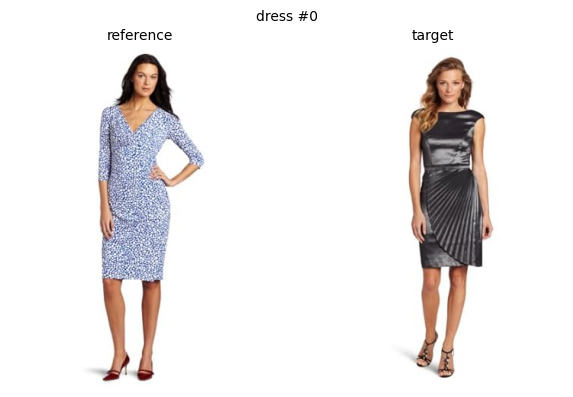

**captions (modifications):**
• is shiny and silver with shorter sleeves
• fit and flare

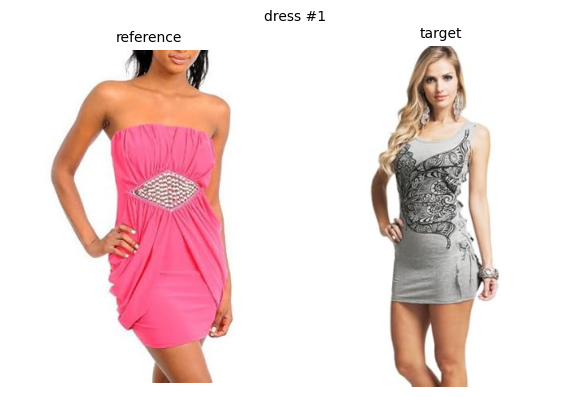

**captions (modifications):**
• is grey with black design
• is a light printed short dress

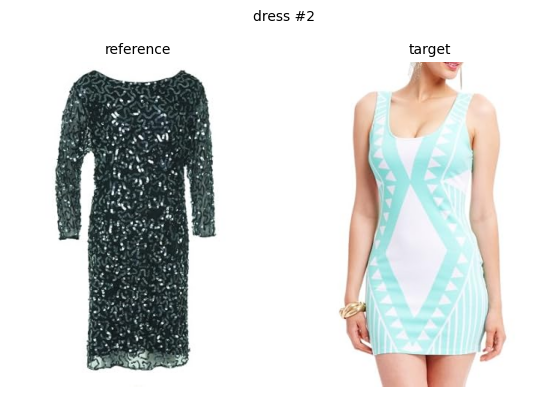

**captions (modifications):**
• is a solid red color
• shorter and tighter with more blue and white

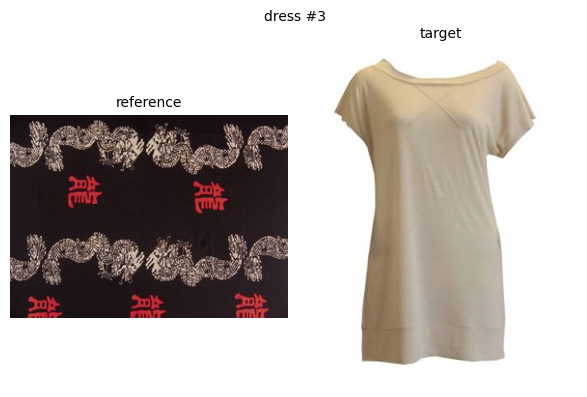

**captions (modifications):**
• is a plain white feminine t shirt
• is a tan shirt.

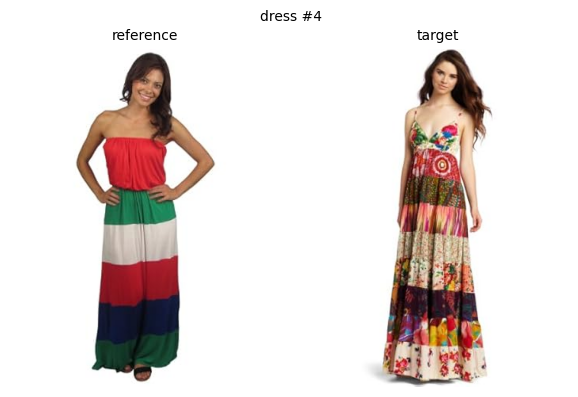

**captions (modifications):**
• has thin straps and different pattern
• more autumn colored and longer

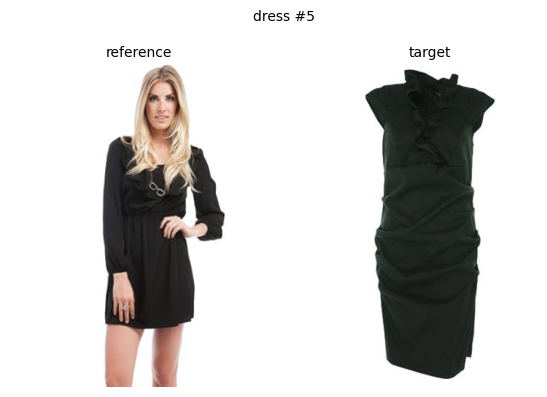

**captions (modifications):**
• is longer and more sculptural
• rushed solid green

### FashionIQ — shirt (n=4)

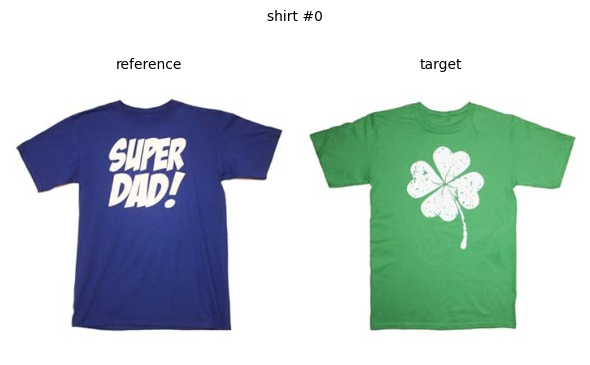

**captions (modifications):**
• is green with a four leaf clover
• is green and has no text

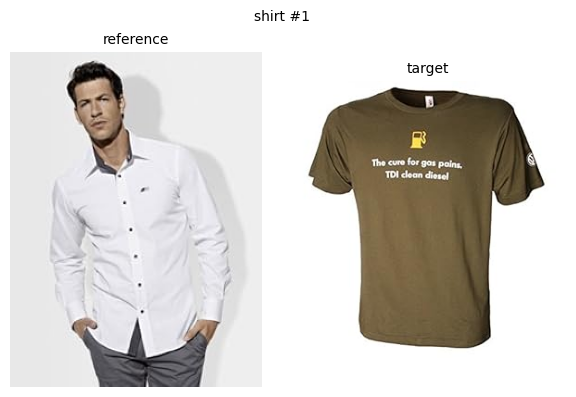

**captions (modifications):**
• Is a brown tee shirt with diseal logo
• is darker and has short sleeves

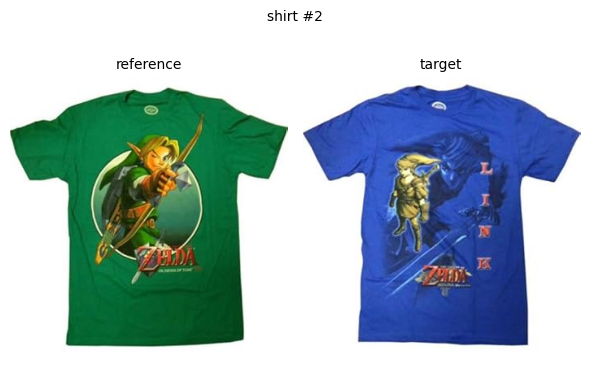

**captions (modifications):**
• is dark blue
• is blue with a different character.

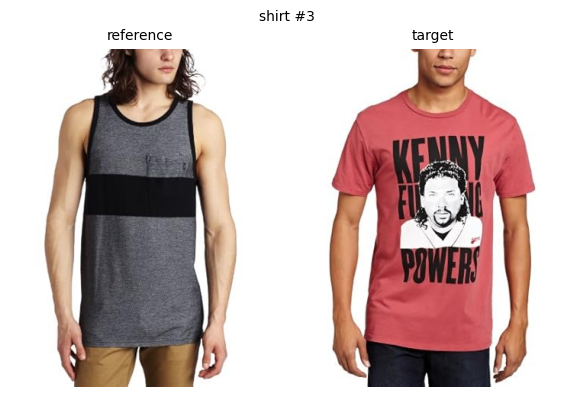

**captions (modifications):**
• is red and a tshirt
• more warmer colors

### FashionIQ — toptee (n=4)

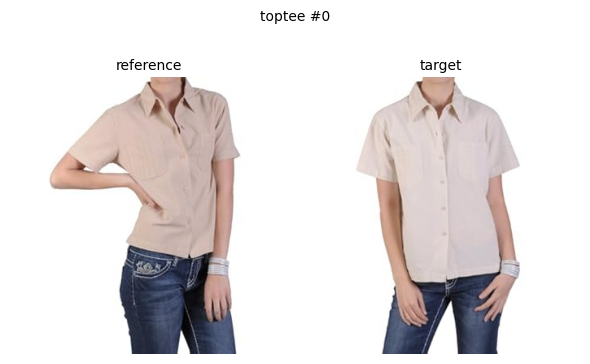

**captions (modifications):**
• is the same
• appears to be exactly the same

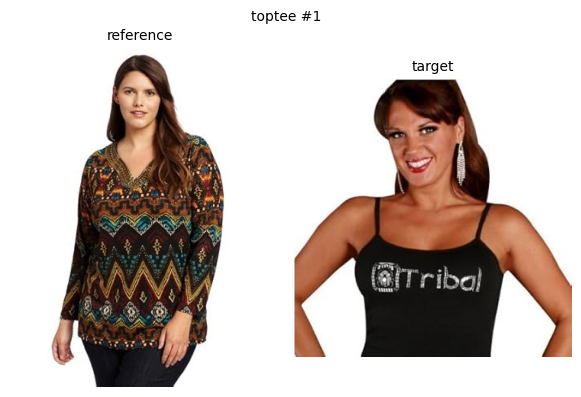

**captions (modifications):**
• i taank top
• has spaghetti straps

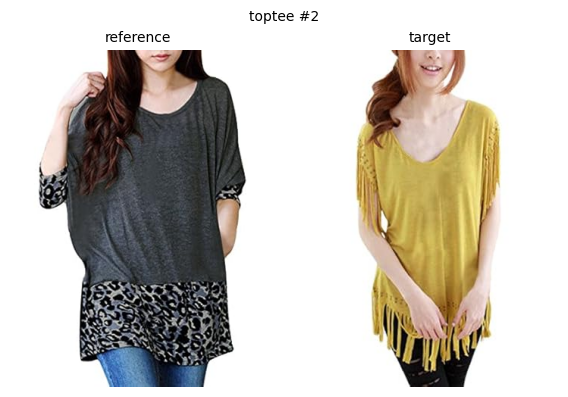

**captions (modifications):**
• is yellow with fringe
• is yellow with shorter sleeves

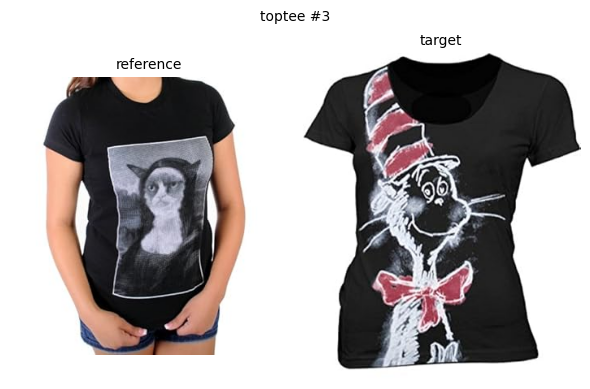

**captions (modifications):**
• The shirt is black with the cat in hat.
• has the Cat in the Hat on it

In [7]:
# Render FashionIQ triplets for all 3 categories
for cat in ['dress', 'shirt', 'toptee']:
    display(Markdown(f'### FashionIQ — {cat} (n={len(samples[cat])})'))
    for idx, s in enumerate(samples[cat]):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))
        caps_md = render_fiq_triplet(ax1, ax2, s['ref_img'], s['tgt_img'], s['triplet']['captions'], s['enh'])
        fig.suptitle(f"{cat} #{idx}", fontsize=10)
        plt.tight_layout()
        plt.show()
        display(Markdown(f"**captions (modifications):**\n{caps_md}"))

## 3. FACap — structure, categories, and modification texts

FACap committed all its triplet JSONs and image-caption JSONs directly to the repo — no external download needed for the annotations. The images themselves reference Fashion200k paths (`f200k_images/dresses/.../xxx.jpeg`), which need Fashion200k downloaded separately. For tonight we only need the text side.

In [8]:
facap_cats = ['dress', 'jacket', 'outfit', 'pants', 'skirt', 'top']
facap_stats = []
facap_sample_triplets = {}
facap_captions_by_cat = {}
for cat in facap_cats:
    with open(FACAP / 'cir_triplets' / f'{cat}_train_triplets.json') as f:
        trips = json.load(f)
    with open(FACAP / 'image_captions' / f'{cat}_train_captions.json') as f:
        caps = json.load(f)  # dict: image_path -> caption
    facap_stats.append({'category': cat, 'n_triplets': len(trips), 'n_unique_image_captions': len(caps)})
    facap_sample_triplets[cat] = trips[:5]
    facap_captions_by_cat[cat] = caps

display(Markdown('### FACap — triplet and caption counts (train split)'))
hdr = '| category | # triplets | # image captions |\n|---|---|---|'
rows = [hdr]
total_t, total_c = 0, 0
for r in facap_stats:
    rows.append(f"| {r['category']} | {r['n_triplets']:,} | {r['n_unique_image_captions']:,} |")
    total_t += r['n_triplets']; total_c += r['n_unique_image_captions']
rows.append(f'| **TOTAL** | **{total_t:,}** | **{total_c:,}** |')
display(Markdown('\n'.join(rows)))

### FACap — triplet and caption counts (train split)

| category | # triplets | # image captions |
|---|---|---|
| dress | 59,082 | 59,082 |
| jacket | 27,122 | 27,122 |
| outfit | 42,544 | 42,544 |
| pants | 31,644 | 31,644 |
| skirt | 35,120 | 35,120 |
| top | 32,168 | 32,168 |
| **TOTAL** | **227,680** | **227,680** |

In [9]:
# Show sample FACap triplets across categories — modification text + target image caption
display(Markdown('### FACap — sample triplets (text only; Fashion200k images not downloaded)'))
for cat in facap_cats:
    display(Markdown(f'**{cat}**'))
    for idx, t in enumerate(facap_sample_triplets[cat][:3]):
        tgt_cap = facap_captions_by_cat[cat].get(t['target'], '(no caption)')
        display(Markdown(
            f"- *{cat} #{idx}*\n"
            f"  - **candidate path:** `{t['candidate']}`\n"
            f"  - **target path:** `{t['target']}`\n"
            f"  - **modification:** {t['captions'][0]}\n"
            f"  - **target caption:** {tgt_cap[:350]}{'…' if len(tgt_cap)>350 else ''}"
        ))

### FACap — sample triplets (text only; Fashion200k images not downloaded)

**dress**

- *dress #0*
  - **candidate path:** `f200k_images/dresses/casual_and_day_dresses/51727804/51727804_0.jpeg`
  - **target path:** `f200k_images/dresses/mini_and_short_dresses/89255983/89255983_0.jpeg`
  - **modification:** The dress is more fitted and shorter, with a vibrant red color and bi-stretch fabric, while maintaining a smooth texture and a round neckline.
  - **target caption:** The dress is a vibrant red, featuring a fitted silhouette that accentuates the body's shape. It has a smooth texture with no visible patterns. The dress is designed with a bi-stretch fabric, which allows for a comfortable fit while maintaining a sleek appearance. The sleeves are short, ending around the mid-bicep, and the neckline is a simple, roun…

- *dress #1*
  - **candidate path:** `f200k_images/dresses/casual_and_day_dresses/54686996/54686996_0.jpeg`
  - **target path:** `f200k_images/dresses/maxi_and_long_dresses/90675985/90675985_2.jpeg`
  - **modification:** The dress is longer and more flowing, with a navy blue base and geometric patterns, featuring short puffed sleeves instead of a halter neckline.
  - **target caption:** The dress is a long, flowing maxi style with a navy blue base color. It features a detailed pattern of white and lighter blue geometric shapes and motifs that create a visually interesting contrast against the darker fabric. The texture appears to be smooth, suggesting a silky or satin-like material. The dress has short sleeves that are slightly pu…

- *dress #2*
  - **candidate path:** `f200k_images/dresses/casual_and_day_dresses/54686996/54686996_1.jpeg`
  - **target path:** `f200k_images/dresses/casual_and_day_dresses/91354634/91354634_0.jpeg`
  - **modification:** The dress is longer and more relaxed, with a V-neckline and long sleeves, featuring a soft, lightweight texture and earthy tones instead of a metallic floral print.
  - **target caption:** The dress is a multicolor silk garment with a loose, flowing silhouette. It features a blend of earthy tones, including shades of beige, brown, and hints of blue, creating a subtle, natural pattern. The texture of the fabric appears soft and lightweight, suggesting a comfortable and airy feel. The dress has a V-neckline and a button-down front, add…

...

- *skirt #2*
  - **candidate path:** `f200k_images/skirts/knee_length_skirts/41940060/41940060_0.jpeg`
  - **target path:** `f200k_images/skirts/maxi_skirts/90895547/90895547_0.jpeg`
  - **modification:** The skirt is longer with a flowing flared silhouette in a neutral gray color, featuring a slightly textured linen-blend fabric instead of a smooth color-blocked design.
  - **target caption:** The skirt in the image is a midi-length garment with a flared silhouette, giving it a flowing and elegant appearance. It is made of a linen-blend fabric, which suggests a lightweight and breathable material, perfect for warmer weather. The color of the skirt is a neutral gray, which is versatile and can easily be paired with various tops and access…

**top**

- *top #0*
  - **candidate path:** `f200k_images/tops/shirts/88809603/88809603_0.jpeg`
  - **target path:** `f200k_images/tops/shirts/76177107/76177107_5.jpeg`
  - **modification:** The top is shorter, more structured with a combination of red and blue colors, and features mid-forearm sleeves while being tucked into the pants.
  - **target caption:** The top is a plaid shirt with a combination of red, blue, and white colors. It has a classic collar and a button-up front. The sleeves are rolled up to the mid-forearm, and the shirt is tucked into the pants, giving it a neat and casual appearance. The fabric appears to be a soft, possibly cotton blend, which is suitable for a breezy, foxy look. Th…

- *top #1*
  - **candidate path:** `f200k_images/tops/shirts/88809603/88809603_1.jpeg`
  - **target path:** `f200k_images/tops/shirts/90988334/90988334_0.jpeg`
  - **modification:** The top is bolder with a boyfriend style, featuring a red plaid pattern and longer sleeves that extend to the wrists.
  - **target caption:** The top is a red boyfriend-style plaid shirt. It features a classic plaid pattern with intersecting lines in shades of red, white, and a hint of blue. The shirt has a relaxed fit with a slightly oversized cut, which is characteristic of a boyfriend style. The sleeves are long, extending to the wrists, and the shirt appears to be of a medium length,…

- *top #2*
  - **candidate path:** `f200k_images/tops/shirts/88809603/88809603_3.jpeg`
  - **target path:** `f200k_images/tops/shirts/90796214/90796214_1.jpeg`
  - **modification:** The top is softer in pastel colors with shorter sleeves and a mid-forearm roll, providing a slightly more fitted look and casual feel.
  - **target caption:** The top is a multicolor plaid shirt with a relaxed fit. It features a blend of pastel colors, including shades of green, pink, and white, creating a soft and casual look. The plaid pattern is traditional, with intersecting lines that form a series of squares and rectangles. The shirt has a pointed collar and is designed with a yoke across the shoul…

In [10]:
# Modification-text length distribution (tokens ~ words as a proxy)
import statistics
display(Markdown('### FACap — modification text length (word-count proxy for tokens)'))
rows = ['| category | n | mean | median | min | max |', '|---|---|---|---|---|---|']
for cat in facap_cats:
    with open(FACAP / 'cir_triplets' / f'{cat}_train_triplets.json') as f:
        trips = json.load(f)
    lens = [len(t['captions'][0].split()) for t in trips]
    rows.append(f"| {cat} | {len(lens):,} | {statistics.mean(lens):.1f} | {statistics.median(lens):.0f} | {min(lens)} | {max(lens)} |")
display(Markdown('\n'.join(rows)))

### FACap — modification text length (word-count proxy for tokens)

| category | n | mean | median | min | max |
|---|---|---|---|---|---|
| dress | 59,082 | 26.0 | 26 | 15 | 44 |
| jacket | 27,122 | 20.0 | 20 | 13 | 33 |
| outfit | 42,544 | 19.0 | 19 | 4 | 33 |
| pants | 31,644 | 22.3 | 22 | 12 | 41 |
| skirt | 35,120 | 26.7 | 26 | 15 | 43 |
| top | 32,168 | 24.6 | 24 | 12 | 43 |

## 4. enhFashionIQ — FACap's refined FashionIQ validation set

Same ASIN keys as FashionIQ val, so we already paired these with images above in the FashionIQ rendering cell. Here we look at the length distribution to compare against original FashionIQ captions.

In [11]:
import statistics
display(Markdown('### FashionIQ vs. enhFashionIQ — modification length'))
rows = ['| cat | source | n | mean words | median | example |', '|---|---|---|---|---|---|']
for cat in ['dress', 'shirt', 'toptee']:
    with open(FIQ / 'captions' / f'cap.{cat}.val.json') as f:
        fiq = json.load(f)
    fiq_lens = [sum(len(c.split()) for c in t['captions']) for t in fiq]
    example_fiq = ' / '.join(fiq[0]['captions'])[:80]
    rows.append(f"| {cat} | FashionIQ (2-cap concat) | {len(fiq):,} | {statistics.mean(fiq_lens):.1f} | {statistics.median(fiq_lens):.0f} | {example_fiq} |")
    with open(ENHFIQ / f'cap.{cat}.val.json') as f:
        enh_list = json.load(f)
    enh_lens = [len(e['captions'][0].split()) for e in enh_list]
    example_enh = enh_list[0]['captions'][0][:80]
    rows.append(f"| {cat} | enhFashionIQ | {len(enh_list):,} | {statistics.mean(enh_lens):.1f} | {statistics.median(enh_lens):.0f} | {example_enh} |")
display(Markdown('\n'.join(rows)))

### FashionIQ vs. enhFashionIQ — modification length

| cat | source | n | mean words | median | example |
|---|---|---|---|---|---|
| dress | FashionIQ (2-cap concat) | 2,017 | 10.5 | 10 | is shiny and silver with shorter sleeves / fit and flare |
| dress | enhFashionIQ | 3,817 | 19.2 | 19 | The dress is black, sleeveless, and has a flared peplum waist, contrasting with  |
| shirt | FashionIQ (2-cap concat) | 2,038 | 10.5 | 10 | is solid white / is a lighter color |
| shirt | enhFashionIQ | 6,346 | 17.4 | 17 | The shirt is white instead of gray, has a different graphic design, and features |
| toptee | FashionIQ (2-cap concat) | 1,961 | 11.1 | 11 | is the same / appears to be exactly the same |
| toptee | enhFashionIQ | 5,373 | 17.9 | 18 | The toptee has a straight hem that is longer, falling just below the waist. |

## 5. Dataset-fit table — 6 questions, real observations

In [12]:
fit_table = """
| Question | FashionIQ | FACap |
|---|---|---|
| **Composed retrieval format `<ref, mod, target>`?** | ✅ Yes. `candidate`, `target`, `captions` (list of 2 relative modifications). | ✅ Yes. `candidate`, `target`, `captions` (list of 1 detailed modification). |
| **Modifications fine-grained for fashion?** | ⚠️ Mixed. Short phrases like "is longer", "is solid white" — good coverage of color/sleeve/length but many are very coarse. | ✅ Yes — by construction. Average ~23 words, detailed phrasing ("more fitted and shorter, vibrant red color, bi-stretch fabric, round neckline"). Captures sleeve/length/fit/fabric/pattern. |
| **Target caption / product description available?** | ❌ Not directly. Would need separate captioning step for Method A supervision. | ✅ Yes. One detailed caption per image (~80 words each), separate from modifications. Perfect target-side supervision for Method A. |
| **Candidate pool / retrieval protocol clear?** | ✅ Yes. Per-category gallery in `image_splits/` (3,817 dress val / 6,346 shirt / 5,373 toptee). Standard R@10 + R@50 metric. | ⚠️ No explicit val/test split. FACap is the pretraining corpus; evaluation is done on FashionIQ + enhFashionIQ. |
| **Metadata for demo (category, etc.)?** | ⚠️ Just 3 categories. No color/style/fit attribute labels in the core data. | ✅ Rich metadata embedded in paths (e.g., `dresses/mini_and_short_dresses/...`) and in both modification and image captions. |
| **TTS-friendly (sounds natural spoken)?** | ✅ Very natural. "is longer", "is black with straps" — short utterances. | ⚠️ Longer, more descriptive sentences. Natural-language but a mouthful when spoken. May need paraphrasing for more conversational TTS. |
"""
display(Markdown(fit_table))


| Question | FashionIQ | FACap |
|---|---|---|
| **Composed retrieval format `<ref, mod, target>`?** | ✅ Yes. `candidate`, `target`, `captions` (list of 2 relative modifications). | ✅ Yes. `candidate`, `target`, `captions` (list of 1 detailed modification). |
| **Modifications fine-grained for fashion?** | ⚠️ Mixed. Short phrases like "is longer", "is solid white" — good coverage of color/sleeve/length but many are very coarse. | ✅ Yes — by construction. Average ~23 words, detailed phrasing ("more fitted and shorter, vibrant red color, bi-stretch fabric, round neckline"). Captures sleeve/length/fit/fabric/pattern. |
| **Target caption / product description available?** | ❌ Not directly. Would need separate captioning step for Method A supervision. | ✅ Yes. One detailed caption per image (~80 words each), separate from modifications. Perfect target-side supervision for Method A. |
| **Candidate pool / retrieval protocol clear?** | ✅ Yes. Per-category gallery in `image_splits/` (3,817 dress val / 6,346 shirt / 5,373 toptee). Standard R@10 + R@50 metric. | ⚠️ No explicit val/test split. FACap is the pretraining corpus; evaluation is done on FashionIQ + enhFashionIQ. |
| **Metadata for demo (category, etc.)?** | ⚠️ Just 3 categories. No color/style/fit attribute labels in the core data. | ✅ Rich metadata embedded in paths (e.g., `dresses/mini_and_short_dresses/...`) and in both modification and image captions. |
| **TTS-friendly (sounds natural spoken)?** | ✅ Very natural. "is longer", "is black with straps" — short utterances. | ⚠️ Longer, more descriptive sentences. Natural-language but a mouthful when spoken. May need paraphrasing for more conversational TTS. |


## 5b. FACap — sample triplets with real images (bonus)

A few FACap dress triplets visualized with real Fashion200k images, pulled via streaming from the `Marqo/fashion200k` HuggingFace mirror. Shows what a FACap modification + target caption actually corresponds to visually.

Rendering 4 FACap dress triplets with real images …

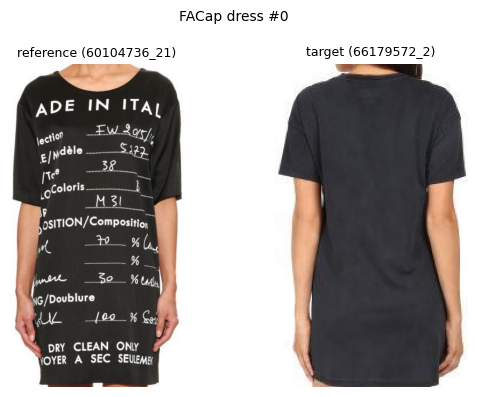

**modification:** The dress is simpler and more minimalist, lacking any graphics or text, with a straight-cut silhouette and no embellishments.

**target-image caption (from FACap):** The dress in the image is a black, short-sleeved tee dress. It has a simple, straight-cut silhouette that falls to a length that is above the knee. The fabric appears to be a smooth, lightweight material, likely cotton or a cotton blend, which gives it a casual and comfortable look. There are no vis…

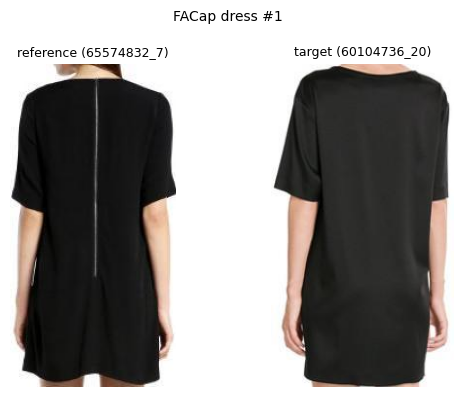

**modification:** The dress is more relaxed and features short sleeves, with a round neckline instead of a straight one, while maintaining a similar length and color.

**target-image caption (from FACap):** The dress in the image is a simple, elegant black t-shirt dress that falls to a length that is just above the knee. It has a relaxed fit with a round neckline and short sleeves that end around the mid-bicep area. The fabric appears smooth and possibly made of a lightweight material, giving it a slee…

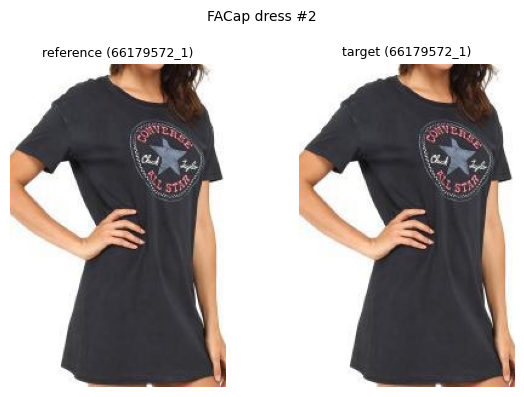

**modification:** The dress is identical in style, color, and design, featuring the same fabric, fit, and graphic details.

**target-image caption (from FACap):** The dress is a short-sleeved tee dress in a solid black color. It features a round neckline and a relaxed fit that extends to a length that falls just above the knee. The fabric appears to be a soft, cotton blend, giving it a comfortable and casual texture. On the front of the dress, there is a prom…

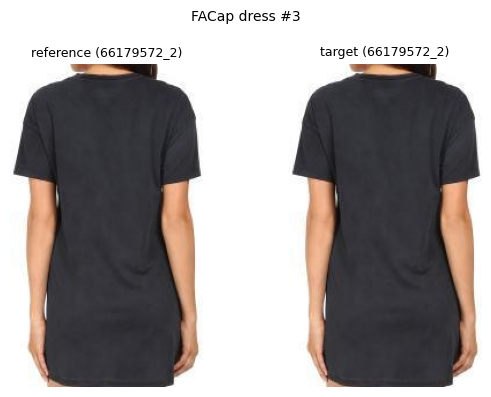

**modification:** The dress is identical in design and fabric, featuring the same minimalist style and short sleeves.

**target-image caption (from FACap):** The dress in the image is a black, short-sleeved tee dress. It has a simple, straight-cut silhouette that falls to a length that is above the knee. The fabric appears to be a smooth, lightweight material, likely cotton or a cotton blend, which gives it a casual and comfortable look. There are no vis…

In [13]:
facap_img_dir = BASE / 'datasets' / 'facap-images'
with open(facap_img_dir / 'dress_sample_manifest.json') as f:
    facap_sample = json.load(f)
with open(FACAP / 'image_captions' / 'dress_train_captions.json') as f:
    dress_img_captions = json.load(f)

def facap_id(path):
    return path.rsplit('/', 1)[-1].removesuffix('.jpeg')

display(Markdown(f'Rendering {len(facap_sample)} FACap dress triplets with real images …'))
for idx, t in enumerate(facap_sample):
    c_id, tgt_id = facap_id(t['candidate']), facap_id(t['target'])
    ref_img = Image.open(facap_img_dir / f'{c_id}.jpeg')
    tgt_img = Image.open(facap_img_dir / f'{tgt_id}.jpeg')
    tgt_caption = dress_img_captions.get(t['target'], '(no caption)')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))
    ax1.imshow(ref_img); ax1.set_title(f'reference ({c_id})', fontsize=9); ax1.axis('off')
    ax2.imshow(tgt_img); ax2.set_title(f'target ({tgt_id})', fontsize=9); ax2.axis('off')
    fig.suptitle(f'FACap dress #{idx}', fontsize=10)
    plt.tight_layout(); plt.show()
    display(Markdown(
        f"**modification:** {t['captions'][0]}\n\n"
        f"**target-image caption (from FACap):** {tgt_caption[:300]}{'…' if len(tgt_caption) > 300 else ''}"
    ))

## 6. Summary 

### Verdict

**FashionIQ:** ✅ production-ready today. Amazon image URLs still resolve in 2026. Natural, TTS-friendly modifications. Standard benchmark with clear eval protocol.

**FACap:** ✅ annotations fully accessible today — all triplet JSONs and image-caption JSONs are committed to the repo. ⚠️ Images require downloading Fashion200k and DeepFashion-MultiModal separately (free, but more setup). Training code is "coming soon," but we're writing our own anyway.

**enhFashionIQ:** ✅ bonus — FACap's refined FashionIQ val set (3,817 dress / 6,346 shirt / 5,373 toptee) uses the same ASIN keys as FashionIQ, so once FashionIQ images are downloaded we can use enhFashionIQ's more detailed refined captions as higher-quality evaluation supervision.

### Recommended staging

1. **Phase 0 (now–next week):** set up TTS + pipeline using FashionIQ only. Fastest to working demo because images are already fetch-able and modifications are short enough for clean TTS.
2. **Phase 1 (pretraining):** download Fashion200k + DeepFashion-MultiModal images, pretrain on FACap's 59k+ triplets per category (6 categories, ~100k+ total triplets).
3. **Phase 2 (eval):** FashionIQ Recall@10/R@50 as the headline metric. enhFashionIQ as a refined secondary eval.

### Open questions

- **Method A vs. Method B first?** Our current proposal draft has A (caption-generation + text retrieval) as baseline and B (direct contrastive embedding) as extension. Build A end-to-end first before touching B, or wire up the B training loop in parallel once the data pipeline is stable?
- **Target caption source for FashionIQ:** FashionIQ has no target-image captions natively. Options: (a) use enhFashionIQ's refined captions where they exist, (b) caption FashionIQ images with the VLM ourselves, (c) use product descriptions from Amazon metadata.
- **TTS pipeline scope:** FACap modifications are ~23 words each — sometimes phrased more like product descriptions than natural speech. Should we paraphrase to conversational form before TTS, or TTS the raw text as-is and accept the slightly stiffer cadence?
- **Audio test set:** do we need real recorded spoken queries for evaluation, or is synthetic TTS acceptable for the first milestone?
- **FACap data release gotcha:** if the paper's authors release updated annotations or license terms later, do we need to pin the current commit we're using?

### Known limitations / gotchas

- FashionIQ image URLs depend on Amazon CDN staying up; spot-checked alive today but long-term risk.
- FACap's Fashion200k dependency means ~100GB+ of raw images for full pretraining.
- FACap license is not stated in repo or project page — clarify before publishing.